<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/kod/DenseNet_Self_Cross_Slice_v2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DenseNet + Self + Cross + Slice Attention — Train/Val + Izole Test

**Akis:**

```
Egitim (train/val, 5 fold) --> 5 BIRLESIK model kaydedilir
  (her model: 3 backbone + self-attn + cross-attn + slice-attn + fusion)
                                   |
                                   v
Izole TEST seti --> 5 modelin FUSION olasiligi (ortalama) --> Final karar
```

**Bu defterin kurallari (diger iki defterle ayni prensipler):**

1. **Test seti tamamen izole.** Test seti EL ILE, ayri 2 klasorden gelir
   (`Slice_CN_test`, `Slice_EMCI_test`). Egitim / validation / model secimine
   HIC dahil edilmez. Sadece en son hucrede, 5 fold ensemble uzerinden
   BIR KEZ degerlendirilir.

2. **Egitim sadece train/validation.** Her fold hastalar bazinda
   %85 train / %15 val (her fold farkli random_state -> 5 farkli model).
   Model secimi yalniz **val_loss** uzerinden (EarlyStopping).

3. **5-Fold + Ensemble.** Her fold tek bir BIRLESIK model uretir.
   5 model kaydedilir. Final tahmin = 5 modelin **fusion** olasiligi
   ortalamasi (soft voting).
   > NOT: Duzlemler modelin icinde self+cross attention ile birlesir;
   > bu yuzden 'duzlem agirligi' yoktur. Onun yerine FOLD agirligi vardir
   > (`FOLD_AGIRLIK`, su an hepsi esit).

4. **Fold ici degisiklikler.** Confusion matrix fold icinden KALDIRILDI;
   loss/accuracy grafikleri KALDI. Her fold sonunda VALIDATION metrikleri
   basilir (accuracy, precision, recall, F1, per-class F1).

5. **Nihai test.** En son hucrede izole test seti, 5 fold fusion ensemble
   uzerinden test edilir: accuracy / precision / recall / F1 + per-class F1
   + confusion matrix + per-plane analiz (5 fold ortalamasi) + grafik.

**Mimari ayni (FIXED):** 3 DenseNet backbone, backbone cikisi LayerNorm,
pos-embedding, SELF-attention (her duzlem kendi icinde), cross-attention
(sag<->kor, ax<->sag, kor<->ax), slice-attention, deep supervision (aux head),
warmup + cosine, NaN guard.

> Yazarin onerisi: Once Cross+Slice defterini calistir. Iyi sonuc verirse bunu
> calistir. Cross+Slice zaten overfit ediyorsa bu daha karmasik modeli
> calistirma (kucuk veride ekstra parametre overfit riski artirir).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seed   : {SEED}")

PyTorch: 2.11.0+cu128
Cihaz  : cuda
GPU    : NVIDIA A100-SXM4-40GB
Seed   : 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slice_v2/'
zip_cn   = drive_path + 'Slice_CN.zip'
zip_emci = drive_path + 'Slice_EMCI.zip'

local_dir = '/content/dataset'
os.makedirs(local_dir, exist_ok=True)

if not os.path.exists(os.path.join(local_dir, 'Slice_CN')):
    print("Slice_CN aciliyor...")
    shutil.unpack_archive(zip_cn, local_dir)

if not os.path.exists(os.path.join(local_dir, 'Slice_EMCI')):
    print("Slice_EMCI aciliyor...")
    shutil.unpack_archive(zip_emci, local_dir)

print("Veri hazir.")

Slice_CN aciliyor...
Slice_EMCI aciliyor...
Veri hazir.


In [ ]:
import zipfile, os

# Test zip'lerinin Drive'daki yeri
test_zip_cn   = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip'
test_zip_emci = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip'

# Yerele acilacak hedef
os.makedirs('/content/dataset_test', exist_ok=True)

for zip_yolu in [test_zip_cn, test_zip_emci]:
    with zipfile.ZipFile(zip_yolu, 'r') as z:
        z.extractall('/content/dataset_test')
    print(f"Acildi: {zip_yolu}")

# Ne cikti, kontrol et
print("\nIcerik:")
for d in sorted(os.listdir('/content/dataset_test')):
    print("  ", d)

Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip
Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip

Icerik:
   Slice_CN
   Slice_EMCI


In [ ]:
import datetime, os

zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"DenseNet_Self_Cross_Slice_FIXED_{zaman_damgasi}"
ANA_KLASOR = f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}'

os.makedirs(ANA_KLASOR, exist_ok=True)
print(f"Ana klasor: {ANA_KLASOR}")

CONFIG = {
    # --- EGITIM verisi (train + validation) ---
    "kaynak_CN"     : '/content/dataset/Slice_CN',
    "kaynak_EMCI"   : '/content/dataset/Slice_EMCI',

    # --- IZOLE TEST verisi (egitime HIC girmez) ---
    # NOT: Asagidaki yollar ORNEKTIR. Kendi test klasorlerinin
    #      dogru yollarini buraya yaz. Ic yapi train ile AYNI olmali:
    #      <klasor>/<hasta_id>/<seans_id>/...sagital/aksiyal/koronal...nii.gz
    "kaynak_CN_test"   : '/content/dataset_test/Slice_CN',
    "kaynak_EMCI_test" : '/content/dataset_test/Slice_EMCI',

    "model_kayit"   : ANA_KLASOR,

    "k_fold"        : 5,
    "batch_size"    : 16,
    "epoch"         : 80,

    # LR'ler (attention patlamasini onlemek icin dusuk)
    "lr_finetune"   : 2e-4,
    "lr_head"       : 5e-4,

    "img_size"      : 224,
    "patience"      : 15,
    "slice_per_plane": 10,
    "val_orani"     : 0.15,    # her fold: %85 train / %15 val
    "num_workers"   : 8,

    "dropout"       : 0.6,
    "min_lr"        : 1e-6,
    "fusion_dim"    : 256,

    "use_class_weights" : True,
    "label_smoothing"   : 0.1,
    "weight_decay"      : 1e-4,
    "grad_clip_norm"    : 0.5,
    "aux_loss_weight"   : 0.3,
    "warmup_epochs"     : 5,

    # Self-Attention
    "sa_dim"        : 1024,
    "sa_heads"      : 8,
    "sa_dropout"    : 0.1,
    "sa_ffn_ratio"  : 1,

    # Cross-Attention
    "ca_dim"        : 1024,
    "ca_heads"      : 8,
    "ca_dropout"    : 0.1,
    "ca_ffn_ratio"  : 1,

    # Slice Attention
    "slice_attn_hidden" : 256,
}

print(f"Batch size        : {CONFIG['batch_size']}")
print(f"Train/Val         : %{int((1-CONFIG['val_orani'])*100)} / %{int(CONFIG['val_orani']*100)}")
print(f"K-Fold            : {CONFIG['k_fold']}")
print(f"Dropout           : {CONFIG['dropout']}")
print(f"LR finetune       : {CONFIG['lr_finetune']}")
print(f"LR head           : {CONFIG['lr_head']}")
print(f"Grad clip         : {CONFIG['grad_clip_norm']}")
print(f"Warmup epochs     : {CONFIG['warmup_epochs']}")
print("\nNOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.")

Ana klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_20_37
Batch size        : 16
Train/Val         : %85 / %15
K-Fold            : 5
Dropout           : 0.6
LR finetune       : 0.0002
LR head           : 0.0005
Grad clip         : 0.5
Warmup epochs     : 5

NOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.


In [ ]:
def dosya_dan_duzlem_cikar(dosya_adi):
    ad_lower = dosya_adi.lower()
    if 'sagital' in ad_lower or 'sagittal' in ad_lower:
        return 'sagital'
    elif 'aksiyal' in ad_lower or 'axial' in ad_lower:
        return 'aksiyal'
    elif 'koronal' in ad_lower or 'coronal' in ad_lower:
        return 'koronal'
    return None


def veri_listesi_olustur(config):
    veriler = []
    for sinif, kaynak in [(0, config["kaynak_CN"]), (1, config["kaynak_EMCI"])]:
        if not os.path.exists(kaynak):
            continue
        for hasta_id in sorted(os.listdir(kaynak)):
            hasta_yol = os.path.join(kaynak, hasta_id)
            if not os.path.isdir(hasta_yol):
                continue
            for seans_id in sorted(os.listdir(hasta_yol)):
                seans_yol = os.path.join(hasta_yol, seans_id)
                if not os.path.isdir(seans_yol):
                    continue
                seans_dict = {
                    'hasta_id': hasta_id, 'seans_id': seans_id,
                    'etiket': sinif,
                    'sagital': [], 'aksiyal': [], 'koronal': []
                }
                for f in sorted(os.listdir(seans_yol)):
                    if f.endswith('.nii.gz') or f.endswith('.nii'):
                        duzlem = dosya_dan_duzlem_cikar(f)
                        if duzlem:
                            seans_dict[duzlem].append(os.path.join(seans_yol, f))
                if (len(seans_dict['sagital']) == config["slice_per_plane"] and
                    len(seans_dict['aksiyal']) == config["slice_per_plane"] and
                    len(seans_dict['koronal']) == config["slice_per_plane"]):
                    veriler.append(seans_dict)
    return veriler


tum_veriler = veri_listesi_olustur(CONFIG)
n_cn   = sum(1 for x in tum_veriler if x['etiket'] == 0)
n_emci = sum(1 for x in tum_veriler if x['etiket'] == 1)
print(f"Toplam seans : {len(tum_veriler)}")
print(f"  CN seans   : {n_cn}")
print(f"  EMCI seans : {n_emci}")
print(f"  Hasta sayisi: {len(set(x['hasta_id'] for x in tum_veriler))}")

Toplam seans : 1990
  CN seans   : 1043
  EMCI seans : 947
  Hasta sayisi: 466


In [ ]:
class MRIMultiViewDataset(Dataset):
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, seans_listesi, img_size=224):
        self.seans_listesi = seans_listesi
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.seans_listesi)

    def _slice_yukle(self, yol):
        img = nib.load(yol).get_fdata().astype(np.float32).squeeze()
        img = np.stack([img]*3, axis=-1)
        return self.transform(img)

    def __getitem__(self, idx):
        seans = self.seans_listesi[idx]
        seans_id = f"{seans['hasta_id']}_{seans['seans_id']}"
        sagital = torch.stack([self._slice_yukle(y) for y in seans['sagital']])
        aksiyal = torch.stack([self._slice_yukle(y) for y in seans['aksiyal']])
        koronal = torch.stack([self._slice_yukle(y) for y in seans['koronal']])
        etiket  = torch.tensor(seans['etiket'], dtype=torch.long)
        return seans_id, sagital, aksiyal, koronal, etiket

print("MRIMultiViewDataset hazir.")

MRIMultiViewDataset hazir.


In [ ]:
class SelfAttentionBlock(nn.Module):
    """Self-Attention blogu (DUZELTILMIS)."""
    def __init__(self, d_model=1024, num_heads=8, dropout=0.1, ffn_ratio=1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ffn_ratio, d_model),
            nn.Dropout(dropout),
        )
        for m in self.ffn.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x


class CrossAttentionBlock(nn.Module):
    """Cross-Attention blogu (DUZELTILMIS)."""
    def __init__(self, d_model=1024, num_heads=8, dropout=0.1, ffn_ratio=1):
        super().__init__()
        self.norm_q  = nn.LayerNorm(d_model)
        self.norm_kv = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm_ffn = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ffn_ratio, d_model),
            nn.Dropout(dropout),
        )
        for m in self.ffn.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, y):
        x_norm = self.norm_q(x)
        y_norm = self.norm_kv(y)
        attn_out, _ = self.attn(query=x_norm, key=y_norm, value=y_norm)
        x = x + attn_out
        x = x + self.ffn(self.norm_ffn(x))
        return x


class SliceAttention(nn.Module):
    def __init__(self, d_model=1024, hidden=256, dropout=0.1):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, x):
        scores = self.scorer(x)
        weights = torch.softmax(scores, dim=1)
        pooled = (x * weights).sum(dim=1)
        return pooled, weights.squeeze(-1)


class MultiViewDenseNetSelfCrossSlice(nn.Module):
    """DUZELTILMIS: backbone cikisina LayerNorm eklendi."""
    def __init__(self, config, dropout_rate=0.6, fusion_dim=256):
        super().__init__()

        self.backbone_sag = self._create_backbone()
        self.backbone_ax  = self._create_backbone()
        self.backbone_kor = self._create_backbone()

        feature_dim = 1024
        self.feat_dim = feature_dim
        self.num_slices = config['slice_per_plane']

        # YENI: Backbone cikisi normalize
        self.norm_backbone_sag = nn.LayerNorm(feature_dim)
        self.norm_backbone_ax  = nn.LayerNorm(feature_dim)
        self.norm_backbone_kor = nn.LayerNorm(feature_dim)

        # Pos embedding (daha kucuk init)
        self.pos_emb_sag = nn.Parameter(torch.zeros(1, self.num_slices, feature_dim))
        self.pos_emb_ax  = nn.Parameter(torch.zeros(1, self.num_slices, feature_dim))
        self.pos_emb_kor = nn.Parameter(torch.zeros(1, self.num_slices, feature_dim))
        nn.init.trunc_normal_(self.pos_emb_sag, std=0.01)
        nn.init.trunc_normal_(self.pos_emb_ax,  std=0.01)
        nn.init.trunc_normal_(self.pos_emb_kor, std=0.01)

        # Self-Attention
        sa_kwargs = dict(
            d_model=config['sa_dim'],
            num_heads=config['sa_heads'],
            dropout=config['sa_dropout'],
            ffn_ratio=config['sa_ffn_ratio']
        )
        self.self_attn_sag = SelfAttentionBlock(**sa_kwargs)
        self.self_attn_ax  = SelfAttentionBlock(**sa_kwargs)
        self.self_attn_kor = SelfAttentionBlock(**sa_kwargs)

        # Cross-Attention
        ca_kwargs = dict(
            d_model=config['ca_dim'],
            num_heads=config['ca_heads'],
            dropout=config['ca_dropout'],
            ffn_ratio=config['ca_ffn_ratio']
        )
        self.ca_sag_kor = CrossAttentionBlock(**ca_kwargs)
        self.ca_ax_sag  = CrossAttentionBlock(**ca_kwargs)
        self.ca_kor_ax  = CrossAttentionBlock(**ca_kwargs)

        # Slice Attention
        slice_kwargs = dict(
            d_model=feature_dim,
            hidden=config['slice_attn_hidden'],
            dropout=config['ca_dropout']
        )
        self.slice_attn_sag = SliceAttention(**slice_kwargs)
        self.slice_attn_ax  = SliceAttention(**slice_kwargs)
        self.slice_attn_kor = SliceAttention(**slice_kwargs)

        self.head_sag = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(128, 2)
        )
        self.head_ax = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(128, 2)
        )
        self.head_kor = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(128, 2)
        )

        self.fusion_classifier = nn.Sequential(
            nn.Linear(feature_dim * 3, fusion_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fusion_dim, 2)
        )

    def _create_backbone(self):
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True
        model.classifier = nn.Identity()
        return model

    def _extract_features(self, backbone, slices, norm_layer):
        B, S, C, H, W = slices.shape
        slices_flat = slices.view(B * S, C, H, W)
        features_flat = backbone(slices_flat)
        features = features_flat.view(B, S, -1)
        features = norm_layer(features)
        return features

    def forward(self, sagital, aksiyal, koronal, return_plane_logits=False):
        # 1) Backbone + LayerNorm
        feat_sag = self._extract_features(self.backbone_sag, sagital, self.norm_backbone_sag)
        feat_ax  = self._extract_features(self.backbone_ax,  aksiyal, self.norm_backbone_ax)
        feat_kor = self._extract_features(self.backbone_kor, koronal, self.norm_backbone_kor)

        # 2) Pos embedding
        feat_sag = feat_sag + self.pos_emb_sag
        feat_ax  = feat_ax  + self.pos_emb_ax
        feat_kor = feat_kor + self.pos_emb_kor

        # 3) Self-Attention
        feat_sag = self.self_attn_sag(feat_sag)
        feat_ax  = self.self_attn_ax (feat_ax)
        feat_kor = self.self_attn_kor(feat_kor)

        # 4) Cross-Attention
        feat_sag = self.ca_sag_kor(feat_sag, feat_kor)
        feat_ax  = self.ca_ax_sag (feat_ax,  feat_sag)
        feat_kor = self.ca_kor_ax (feat_kor, feat_ax)

        # 5) Slice Attention
        pooled_sag, _ = self.slice_attn_sag(feat_sag)
        pooled_ax,  _ = self.slice_attn_ax (feat_ax)
        pooled_kor, _ = self.slice_attn_kor(feat_kor)

        # 6) Fusion
        fused = torch.cat([pooled_sag, pooled_ax, pooled_kor], dim=1)
        fusion_logits = self.fusion_classifier(fused)

        if return_plane_logits:
            return (fusion_logits,
                    self.head_sag(pooled_sag),
                    self.head_ax (pooled_ax),
                    self.head_kor(pooled_kor))
        return fusion_logits


def multiview_olustur(config, dropout_rate=0.6, fusion_dim=256):
    model = MultiViewDenseNetSelfCrossSlice(
        config, dropout_rate=dropout_rate, fusion_dim=fusion_dim
    )
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Toplam param   : {total:,}")
    print(f"Egitilen param : {trainable:,} ({100*trainable/total:.2f}%)")
    print(f"Dropout        : {dropout_rate}")
    print(f"FFN ratio      : 1 (azaltildi)")
    return model.to(DEVICE)

print("Model olusturuluyor (test)...")
_t = multiview_olustur(CONFIG, 0.6, 256)
del _t; torch.cuda.empty_cache()
print("MultiViewDenseNetSelfCrossSlice (FIXED) hazir.")

Model olusturuluyor (test)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
MultiViewDenseNetSelfCrossSlice (FIXED) hazir.


In [ ]:
def multiview_degerlendir(model, loader, kayip_fn=None):
    model.eval()
    y_true, y_pred = [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for _, sag, ax, kor, lbls in loader:
            sag = sag.to(DEVICE)
            ax  = ax.to(DEVICE)
            kor = kor.to(DEVICE)
            lbls = lbls.to(DEVICE)
            logits = model(sag, ax, kor)
            if kayip_fn is not None:
                total_loss += kayip_fn(logits, lbls).item()
                n_batches += 1
            preds = logits.argmax(dim=1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    return y_true, y_pred, avg_loss

print("Degerlendirme fonksiyonu hazir.")

Degerlendirme fonksiyonu hazir.


In [ ]:
class EarlyStopping:
    def __init__(self, patience=15, path='best.pth'):
        self.patience   = patience
        self.path       = path
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_acc   = -1.0
        self.early_stop = False

    def __call__(self, val_loss, val_acc, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_acc  = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

print("EarlyStopping hazir.")

EarlyStopping hazir.


In [ ]:
def egitimi_baslat_ve_yedekle(veriler, config):
    """
    5-fold egitim — SADECE train/val.

    >>> Test seti bu fonksiyona HIC girmez. <<<
    Test seti disarida, izole tutulur ve yalniz en son hucrede
    5 fold ensemble uzerinden degerlendirilir.

    Her fold:
      - Hastalar bazinda %85 train / %15 val (her fold farkli random_state,
        boylece 5 farkli BIRLESIK model -> ensemble uyeleri).
      - Model secimi val_loss uzerinden (EarlyStopping).
      - Confusion matrix fold icinden KALDIRILDI; grafikler KALDI.
      - Fold sonunda en iyi model VALIDATION uzerinde raporlanir.
      - Model kaydi: 'multiview_fold_{fold}.pth'

    Dondurur: fold_results (her fold icin VALIDATION metrikleri)
    """
    os.makedirs(config["model_kayit"], exist_ok=True)

    unique_pats = sorted(set(x['hasta_id'] for x in veriler))
    fold_results = []
    csv_yolu = os.path.join(config["model_kayit"], "deney_sonuclari.csv")

    for fold in range(1, config["k_fold"] + 1):
        # Hastalar bazinda %85 train / %15 val (fold'a gore degisen seed)
        tr_ids, val_ids = train_test_split(
            unique_pats, test_size=config["val_orani"], random_state=SEED + fold
        )

        tr_seans  = [x for x in veriler if x['hasta_id'] in set(tr_ids)]
        val_seans = [x for x in veriler if x['hasta_id'] in set(val_ids)]

        # SIZINTI KONTROLU (sadece train-val)
        tr_hastalar  = set(s['hasta_id'] for s in tr_seans)
        val_hastalar = set(s['hasta_id'] for s in val_seans)
        assert len(tr_hastalar & val_hastalar) == 0, "SIZINTI Train-Val!"

        print(f"\n{'='*70}\n FOLD {fold}")
        print(f"   Train: {len(tr_ids)} hasta / {len(tr_seans)} seans")
        print(f"   Val  : {len(val_ids)} hasta / {len(val_seans)} seans")
        print(f"   SIZINTI KONTROLU (Train-Val): OK")

        for set_adi, set_data in [('Train', tr_seans), ('Val', val_seans)]:
            n_cn   = sum(1 for x in set_data if x['etiket'] == 0)
            n_emci = sum(1 for x in set_data if x['etiket'] == 1)
            toplam = n_cn + n_emci
            print(f"   {set_adi}: CN={n_cn:3d} ({100*n_cn/toplam:5.1f}%) | "
                  f"EMCI={n_emci:3d} ({100*n_emci/toplam:5.1f}%)")
        print(f"{'='*70}")

        if config["use_class_weights"]:
            n_cn_tr   = sum(1 for x in tr_seans if x['etiket'] == 0)
            n_emci_tr = sum(1 for x in tr_seans if x['etiket'] == 1)
            n_total   = n_cn_tr + n_emci_tr
            w_cn   = n_total / (2 * n_cn_tr)
            w_emci = n_total / (2 * n_emci_tr)
            class_weights = torch.tensor([w_cn, w_emci], dtype=torch.float).to(DEVICE)
            print(f"  Class Weights -> CN: {w_cn:.3f}, EMCI: {w_emci:.3f}")
        else:
            class_weights = None

        train_loader = DataLoader(
            MRIMultiViewDataset(tr_seans, img_size=config["img_size"]),
            batch_size=config["batch_size"], shuffle=True,
            num_workers=config["num_workers"], pin_memory=True,
            worker_init_fn=seed_worker, generator=g
        )
        val_loader = DataLoader(
            MRIMultiViewDataset(val_seans, img_size=config["img_size"]),
            batch_size=config["batch_size"], shuffle=False,
            num_workers=config["num_workers"], pin_memory=True
        )

        model = multiview_olustur(
            config, dropout_rate=config["dropout"], fusion_dim=config["fusion_dim"]
        )

        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name and 'norm_backbone' not in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config["lr_finetune"],
             'weight_decay': config["weight_decay"]},
            {'params': head_params,     'lr': config["lr_head"],
             'weight_decay': config["weight_decay"]}
        ])

        # Warmup + Cosine scheduler
        warmup_epochs = config["warmup_epochs"]
        total_epochs = config["epoch"]

        def lr_lambda(epoch):
            if epoch < warmup_epochs:
                return 0.01 + 0.99 * (epoch / warmup_epochs)
            else:
                progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
                return 0.5 * (1 + np.cos(np.pi * progress))

        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

        crit = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=config["label_smoothing"]
        )
        aux_w = config["aux_loss_weight"]

        m_path = os.path.join(config["model_kayit"], f'multiview_fold_{fold}.pth')
        es = EarlyStopping(patience=config["patience"], path=m_path)

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, config["epoch"] + 1):
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0
            nan_count = 0

            for _, sag, ax, kor, lbls in train_loader:
                sag = sag.to(DEVICE); ax = ax.to(DEVICE); kor = kor.to(DEVICE)
                lbls = lbls.to(DEVICE)
                optimizer.zero_grad()
                fusion_out, sag_out, ax_out, kor_out = model(
                    sag, ax, kor, return_plane_logits=True
                )

                if torch.isnan(fusion_out).any() or torch.isinf(fusion_out).any():
                    nan_count += 1
                    continue

                loss_fusion = crit(fusion_out, lbls)
                loss_aux    = (crit(sag_out, lbls)
                               + crit(ax_out,  lbls)
                               + crit(kor_out, lbls)) / 3.0
                loss = loss_fusion + aux_w * loss_aux

                if torch.isnan(loss) or torch.isinf(loss):
                    nan_count += 1
                    continue

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=config["grad_clip_norm"]
                )
                optimizer.step()

                tr_loss    += loss.item()
                preds       = fusion_out.argmax(dim=1)
                tr_correct += (preds == lbls).sum().item()
                tr_total   += lbls.size(0)

            if tr_total == 0:
                print(f"   Epoch {epoch:02d}: TUM batch'ler NaN, fold durduruluyor!")
                break

            train_loss = tr_loss / max(1, len(train_loader) - nan_count)
            train_acc  = tr_correct / tr_total

            y_v_t, y_v_p, val_loss = multiview_degerlendir(model, val_loader, kayip_fn=crit)
            val_acc = accuracy_score(y_v_t, y_v_p)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            improved = es(val_loss, val_acc, model)
            mark = "*" if improved else " "
            lr_bb = optimizer.param_groups[0]['lr']
            nan_str = f" [NaN:{nan_count}]" if nan_count > 0 else ""
            print(f"   Epoch {epoch:02d} {mark} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"LR_bb: {lr_bb:.2e}{nan_str}")

            if epoch in [1, 5, 10, 15]:
                n_cn_v = sum(1 for p in y_v_p if p == 0)
                n_em_v = sum(1 for p in y_v_p if p == 1)
                print(f"       Val tahmin: CN={n_cn_v}, EMCI={n_em_v}")

            if es.early_stop:
                print(f"   Sabir tukendi, Fold {fold} durduruldu (epoch {epoch}).")
                break
            scheduler.step()

        # Grafik (KORUNDU)
        if len(history['train_loss']) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            ep_range = range(1, len(history['train_loss']) + 1)
            axes[0].plot(ep_range, history['train_loss'], 'b-', label='Train Loss', lw=2)
            axes[0].plot(ep_range, history['val_loss'],   'r-', label='Val Loss',   lw=2)
            axes[0].set_title(f'Fold {fold} Loss')
            axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
            axes[0].legend(); axes[0].grid(True, alpha=0.3)
            axes[1].plot(ep_range, history['train_acc'], 'b-', label='Train Acc', lw=2)
            axes[1].plot(ep_range, history['val_acc'],   'r-', label='Val Acc',   lw=2)
            axes[1].set_title(f'Fold {fold} Accuracy')
            axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
            axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0,1])
            plt.tight_layout()
            plt.savefig(os.path.join(config["model_kayit"], f'fold_{fold}_egitim_grafigi.png'),
                        dpi=100, bbox_inches='tight')
            plt.show()

            pd.DataFrame(history).to_csv(
                os.path.join(config["model_kayit"], f'fold_{fold}_metrik_gecmisi.csv'),
                index=False
            )

        if not os.path.exists(m_path):
            print(f"   Fold {fold}: Model kaydedilmemis (egitim basarisiz), atlaniyor")
            continue

        # === En iyi modeli yukle ve VALIDATION uzerinde degerlendir ===
        # (Confusion matrix fold icinde YOK; sadece metrikler)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        y_v, y_vp, _ = multiview_degerlendir(model, val_loader)

        p, r, f, _ = precision_recall_fscore_support(y_v, y_vp, average='weighted', zero_division=0)
        p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
            y_v, y_vp, average=None, labels=[0, 1], zero_division=0
        )
        val_acc_best = accuracy_score(y_v, y_vp)

        print(f"\n{'='*70}\n FOLD {fold} VALIDATION SONUCLARI\n{'='*70}")
        print(f"   Val Accuracy  : {val_acc_best:.4f}")
        print(f"   Precision     : {p:.4f}")
        print(f"   Recall        : {r:.4f}")
        print(f"   F1 Score      : {f:.4f}")
        print(f"   Per-Class F1  : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f} | "
              f"Fark={abs(f_pc[0]-f_pc[1]):.4f} "
              f"{'KONTROL ET' if abs(f_pc[0]-f_pc[1]) > 0.10 else 'Normal'}")
        print(f"   Best Val Loss : {es.best_loss:.4f}")
        print(f"   Model kaydi   : {m_path}")
        print(f"{'='*70}\n")

        fold_skoru = {
            'fold': fold,
            'val_acc'  : val_acc_best,
            'val_prec' : p, 'val_rec': r, 'val_f1': f,
            'val_f1_cn': f_pc[0], 'val_f1_emci': f_pc[1],
            'best_val_loss': es.best_loss, 'best_val_acc': es.best_acc,
            'durduran_epoch': len(history['train_loss'])
        }
        fold_results.append(fold_skoru)
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)

        del model
        torch.cuda.empty_cache()

    return fold_results

print("Egitim fonksiyonu hazir (SADECE train/val; test izole; warmup + NaN kontrol).")

Egitim fonksiyonu hazir (SADECE train/val; test izole; warmup + NaN kontrol).


DENSENET + SELF + CROSS + SLICE ATTENTION (train/val, test izole)


 FOLD 1
   Train: 396 hasta / 1704 seans
   Val  : 70 hasta / 286 seans
   SIZINTI KONTROLU (Train-Val): OK
   Train: CN=903 ( 53.0%) | EMCI=801 ( 47.0%)
   Val: CN=140 ( 49.0%) | EMCI=146 ( 51.0%)
  Class Weights -> CN: 0.944, EMCI: 1.064
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
   Epoch 01 * | Train Loss: 0.8922 | Train Acc: 0.5734 | Val Loss: 0.6790 | Val Acc: 0.6049 | LR_bb: 2.00e-06
       Val tahmin: CN=43, EMCI=243
   Epoch 02   | Train Loss: 0.8401 | Train Acc: 0.6614 | Val Loss: 0.8458 | Val Acc: 0.5350 | LR_bb: 4.16e-05
   Epoch 03   | Train Loss: 0.6010 | Train Acc: 0.8404 | Val Loss: 0.6916 | Val Acc: 0.6224 | LR_bb: 8.12e-05
   Epoch 04   | Train Loss: 0.4570 | Train Acc: 0.9196 | Val Loss: 0.9672 | Val Acc: 0.6119 | LR_bb: 1.21e-04
   Epoch 05   | Train Loss: 0.4014 | Train Acc: 0.9495 | Val Loss: 0.9384 | Val Acc: 0.6084 | LR_bb:

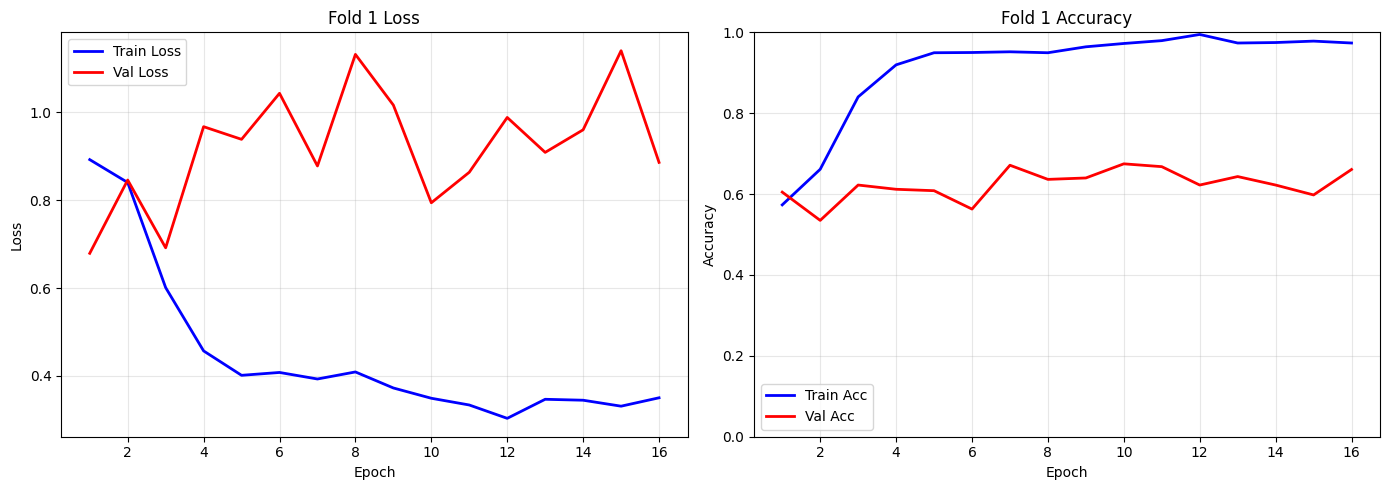


 FOLD 1 VALIDATION SONUCLARI
   Val Accuracy  : 0.6049
   Precision     : 0.6883
   Recall        : 0.6049
   F1 Score      : 0.5494
   Per-Class F1  : CN=0.3825 | EMCI=0.7095 | Fark=0.3270 KONTROL ET
   Best Val Loss : 0.6790
   Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_1.pth


 FOLD 2
   Train: 396 hasta / 1712 seans
   Val  : 70 hasta / 278 seans
   SIZINTI KONTROLU (Train-Val): OK
   Train: CN=881 ( 51.5%) | EMCI=831 ( 48.5%)
   Val: CN=162 ( 58.3%) | EMCI=116 ( 41.7%)
  Class Weights -> CN: 0.972, EMCI: 1.030
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
   Epoch 01 * | Train Loss: 0.8981 | Train Acc: 0.5818 | Val Loss: 0.6590 | Val Acc: 0.6151 | LR_bb: 2.00e-06
       Val tahmin: CN=221, EMCI=57
   Epoch 02   | Train Loss: 0.8354 | Train Acc: 0.6554 | Val Loss: 0.7675 | Val Acc: 0.6547 | LR_bb: 4.16e-

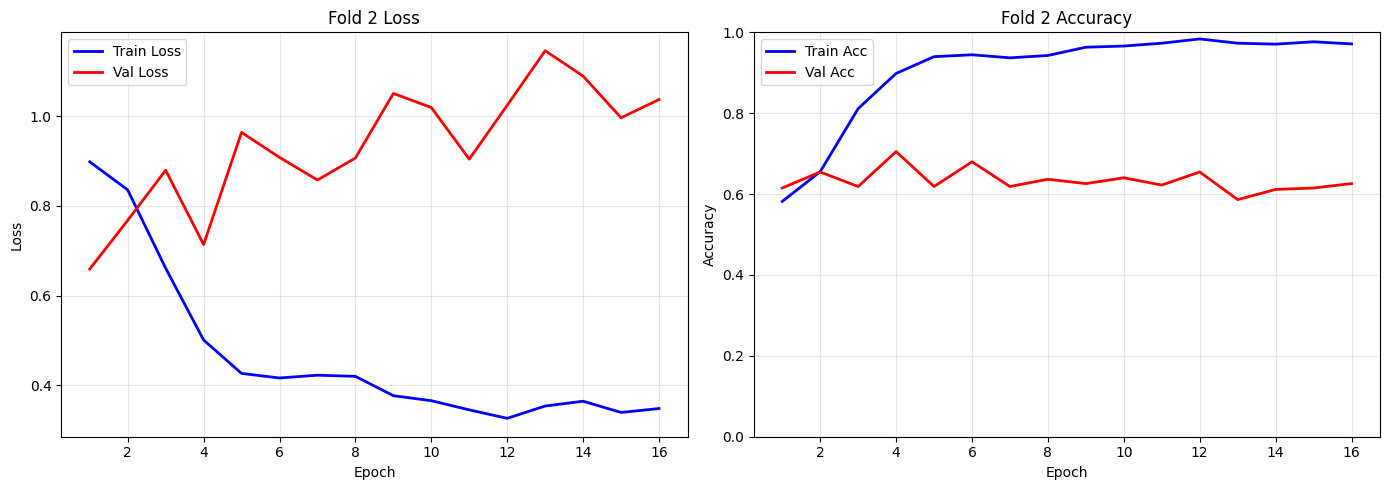


 FOLD 2 VALIDATION SONUCLARI
   Val Accuracy  : 0.6151
   Precision     : 0.6055
   Recall        : 0.6151
   F1 Score      : 0.5791
   Per-Class F1  : CN=0.7206 | EMCI=0.3815 | Fark=0.3391 KONTROL ET
   Best Val Loss : 0.6590
   Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_2.pth


 FOLD 3
   Train: 396 hasta / 1676 seans
   Val  : 70 hasta / 314 seans
   SIZINTI KONTROLU (Train-Val): OK
   Train: CN=868 ( 51.8%) | EMCI=808 ( 48.2%)
   Val: CN=175 ( 55.7%) | EMCI=139 ( 44.3%)
  Class Weights -> CN: 0.965, EMCI: 1.037
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
   Epoch 01 * | Train Loss: 0.9017 | Train Acc: 0.5573 | Val Loss: 0.6658 | Val Acc: 0.5605 | LR_bb: 2.00e-06
       Val tahmin: CN=187, EMCI=127
   Epoch 02 * | Train Loss: 0.8842 | Train Acc: 0.6271 | Val Loss: 0.6336 | Val Acc: 0.6529 | LR_bb: 4.16e

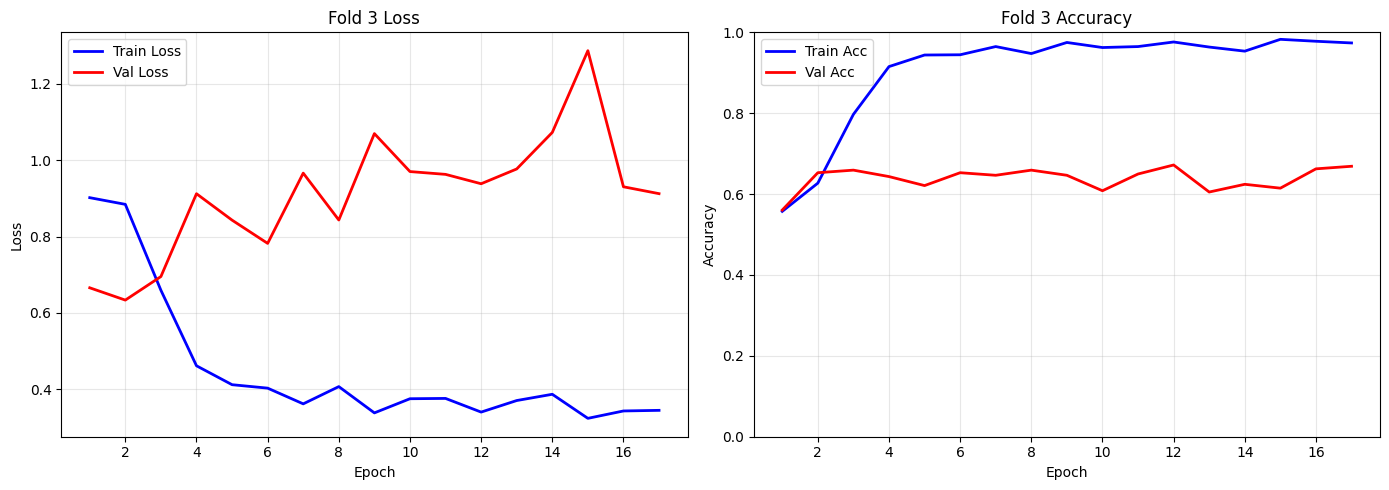


 FOLD 3 VALIDATION SONUCLARI
   Val Accuracy  : 0.6529
   Precision     : 0.6501
   Recall        : 0.6529
   F1 Score      : 0.6479
   Per-Class F1  : CN=0.7078 | EMCI=0.5725 | Fark=0.1352 KONTROL ET
   Best Val Loss : 0.6336
   Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_3.pth


 FOLD 4
   Train: 396 hasta / 1701 seans
   Val  : 70 hasta / 289 seans
   SIZINTI KONTROLU (Train-Val): OK
   Train: CN=888 ( 52.2%) | EMCI=813 ( 47.8%)
   Val: CN=155 ( 53.6%) | EMCI=134 ( 46.4%)
  Class Weights -> CN: 0.958, EMCI: 1.046
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
   Epoch 01 * | Train Loss: 0.9063 | Train Acc: 0.5397 | Val Loss: 0.6527 | Val Acc: 0.6609 | LR_bb: 2.00e-06
       Val tahmin: CN=81, EMCI=208
   Epoch 02   | Train Loss: 0.8363 | Train Acc: 0.6490 | Val Loss: 0.7268 | Val Acc: 0.6782 | LR_bb: 4.16e-

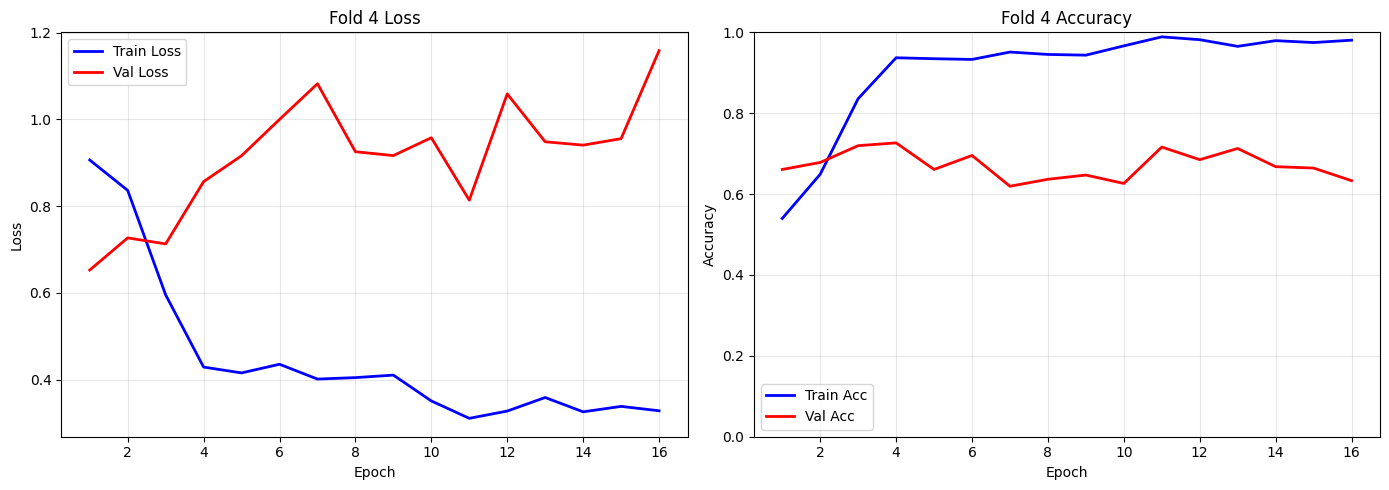


 FOLD 4 VALIDATION SONUCLARI
   Val Accuracy  : 0.6609
   Precision     : 0.7288
   Recall        : 0.6609
   F1 Score      : 0.6444
   Per-Class F1  : CN=0.5847 | EMCI=0.7135 | Fark=0.1287 KONTROL ET
   Best Val Loss : 0.6527
   Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_4.pth


 FOLD 5
   Train: 396 hasta / 1714 seans
   Val  : 70 hasta / 276 seans
   SIZINTI KONTROLU (Train-Val): OK
   Train: CN=923 ( 53.9%) | EMCI=791 ( 46.1%)
   Val: CN=120 ( 43.5%) | EMCI=156 ( 56.5%)
  Class Weights -> CN: 0.928, EMCI: 1.083
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
   Epoch 01 * | Train Loss: 0.8936 | Train Acc: 0.5683 | Val Loss: 0.6570 | Val Acc: 0.6667 | LR_bb: 2.00e-06
       Val tahmin: CN=134, EMCI=142
   Epoch 02 * | Train Loss: 0.8285 | Train Acc: 0.6610 | Val Loss: 0.6090 | Val Acc: 0.6486 | LR_bb: 4.16e

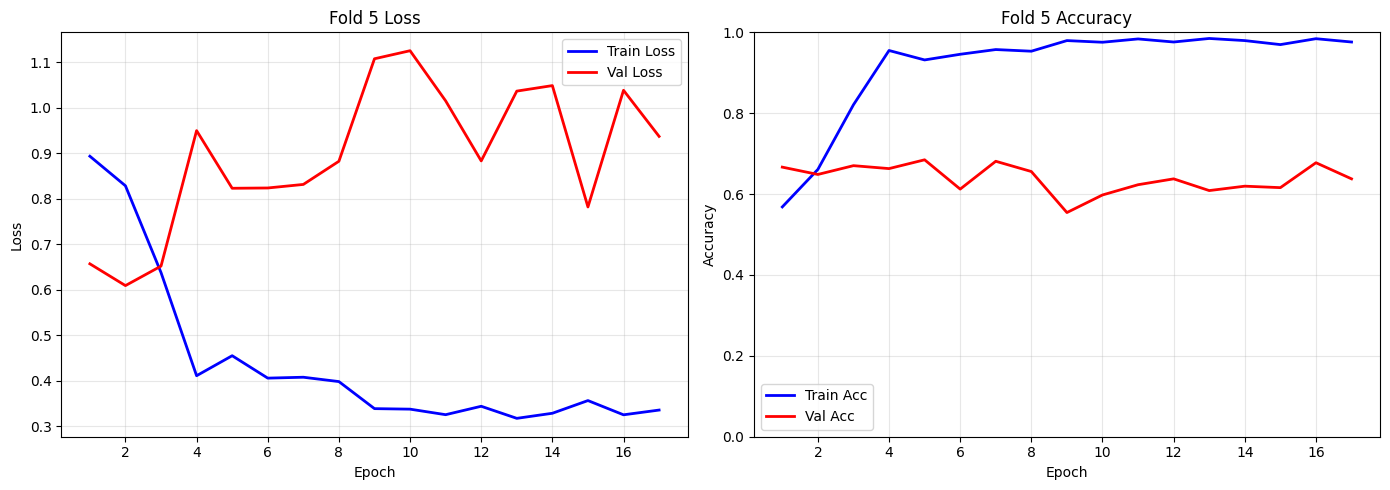


 FOLD 5 VALIDATION SONUCLARI
   Val Accuracy  : 0.6486
   Precision     : 0.6457
   Recall        : 0.6486
   F1 Score      : 0.6373
   Per-Class F1  : CN=0.5314 | EMCI=0.7188 | Fark=0.1874 KONTROL ET
   Best Val Loss : 0.6090
   Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_5.pth


Toplam sure: 73.2 dakika (1.22 saat)


In [ ]:
import time

print(f"{'='*70}")
print(f"DENSENET + SELF + CROSS + SLICE ATTENTION (train/val, test izole)")
print(f"{'='*70}\n")

t0 = time.time()
sonuclar = egitimi_baslat_ve_yedekle(tum_veriler, CONFIG)
sure_toplam = time.time() - t0

print(f"\nToplam sure: {sure_toplam/60:.1f} dakika ({sure_toplam/3600:.2f} saat)")

In [ ]:
if os.path.exists(os.path.join(ANA_KLASOR, "deney_sonuclari.csv")):
    df_sonuc = pd.read_csv(os.path.join(ANA_KLASOR, "deney_sonuclari.csv"))

    print(f"\n{'='*70}")
    print(f"5-FOLD VALIDATION SONUCLARI")
    print(f"{'='*70}")
    print(df_sonuc[['fold', 'val_acc', 'val_f1', 'val_f1_cn', 'val_f1_emci', 'best_val_loss']].to_string(index=False))

    print(f"\nOrtalamalar (VALIDATION):")
    print(f"  Val Acc  : {df_sonuc['val_acc'].mean():.4f} +/- {df_sonuc['val_acc'].std():.4f}")
    print(f"  Val F1   : {df_sonuc['val_f1'].mean():.4f} +/- {df_sonuc['val_f1'].std():.4f}")
    print(f"  CN F1    : {df_sonuc['val_f1_cn'].mean():.4f}")
    print(f"  EMCI F1  : {df_sonuc['val_f1_emci'].mean():.4f}")
    print(f"\nModel dosyalari: {ANA_KLASOR}")
    print("NOT: Bu sayilar VALIDATION'dir, gercek performans degildir.")
    print("     Gercek performans en alttaki NIHAI TEST hucresindedir.")
else:
    print("HENUZ SONUC YOK - egitim henuz tamamlanmadi.")


5-FOLD VALIDATION SONUCLARI
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.604895 0.549443   0.382514     0.709512       0.679006
    2 0.615108 0.579122   0.720627     0.381503       0.659027
    3 0.652866 0.647914   0.707775     0.572549       0.633611
    4 0.660900 0.644422   0.584746     0.713450       0.652727
    5 0.648551 0.637345   0.531401     0.718841       0.609040

Ortalamalar (VALIDATION):
  Val Acc  : 0.6365 +/- 0.0248
  Val F1   : 0.6116 +/- 0.0447
  CN F1    : 0.5854
  EMCI F1  : 0.6192

Model dosyalari: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23
NOT: Bu sayilar VALIDATION'dir, gercek performans degildir.
     Gercek performans en alttaki NIHAI TEST hucresindedir.


## NIHAI TEST — Izole Test Seti + 5-Fold Fusion Ensemble

Asagidaki hucre, egitime HIC girmemis izole test setini okur, kaydedilen
5 birlesik modeli yukler ve her modelin **fusion** olasiligini ortalar
(soft voting). `FOLD_AGIRLIK` ile fold agirliklari degistirilebilir
(su an hepsi esit).

Ayrica per-plane analiz: 5 modelin yardimci kafalarinin (sagital / aksiyal /
koronal) test ortalamasi da raporlanir.


TEST seti: 296 seans  (CN=148, EMCI=148)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_1.pth)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
  fold 2 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_2.pth)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
  fold 3 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23/multiview_fold_3.pth)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
  fold 4 tamam

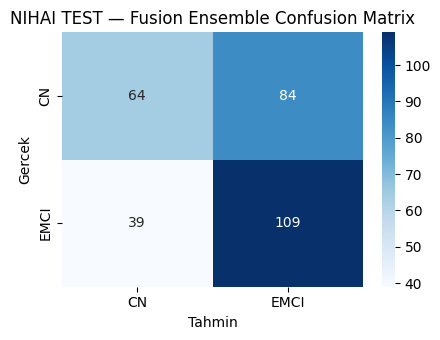

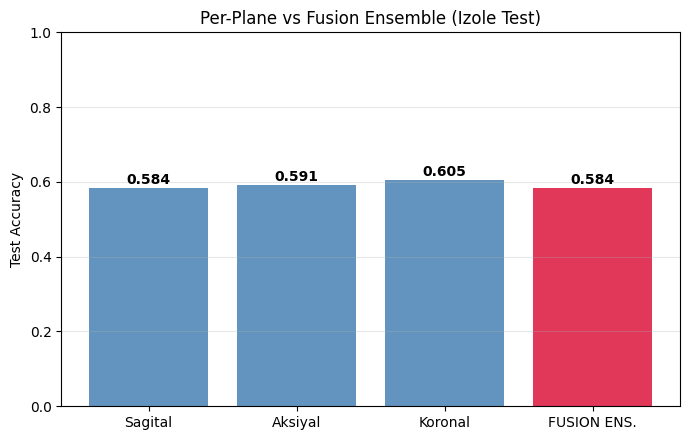


Kaydedildi: final_test_tahminler.csv, final_test_ozet.csv
Bitti.


In [ ]:
# ============================================================
# NIHAI TEST: izole test seti + 5 fold FUSION ensemble
# ============================================================
import numpy as np
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23'

# --- 1) Izole test verisini oku (train ile AYNI yapida) ---
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]

test_veriler = veri_listesi_olustur(test_config)
n_cn_te   = sum(1 for x in test_veriler if x['etiket'] == 0)
n_emci_te = sum(1 for x in test_veriler if x['etiket'] == 1)
print(f"TEST seti: {len(test_veriler)} seans  (CN={n_cn_te}, EMCI={n_emci_te})")
assert len(test_veriler) > 0, "Test seti bos! kaynak_CN_test / kaynak_EMCI_test yollarini kontrol et."

# Gercek etiket: sid -> etiket
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# --- 2) Fold agirliklari (degistirilebilir) ---
FOLD_AGIRLIK = {1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0}

# --- 3) Test loader (tek sefer; sira sabit) ---
test_loader = DataLoader(
    MRIMultiViewDataset(test_veriler, img_size=CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

# --- 4) Tahmin fonksiyonu: fusion + 3 duzlem kafasi olasiliklarini dondurur ---
def tahmin_al_multiview(model, loader):
    model.eval()
    sids_all = []
    p_fusion, p_sag, p_ax, p_kor = [], [], [], []
    with torch.no_grad():
        for sids, sag, ax, kor, lbls in loader:
            sag = sag.to(DEVICE); ax = ax.to(DEVICE); kor = kor.to(DEVICE)
            fus, s_out, a_out, k_out = model(sag, ax, kor, return_plane_logits=True)
            sids_all.extend(list(sids))
            p_fusion.extend(torch.softmax(fus,   dim=1).cpu().numpy().tolist())
            p_sag.extend(   torch.softmax(s_out, dim=1).cpu().numpy().tolist())
            p_ax.extend(    torch.softmax(a_out, dim=1).cpu().numpy().tolist())
            p_kor.extend(   torch.softmax(k_out, dim=1).cpu().numpy().tolist())
    return sids_all, p_fusion, p_sag, p_ax, p_kor

# --- 5) 5 fold modelini yukle, agirlikli topla ---
toplam_agirlik = sum(FOLD_AGIRLIK.values())
fusion_sum = {}                                  # sid -> agirlikli fusion olasilik toplami
plane_sum  = {'sag': {}, 'ax': {}, 'kor': {}}    # per-plane (esit ortalama)

bulunan_fold = 0
for fold in range(1, CONFIG["k_fold"] + 1):
    m_path = os.path.join(ANA_KLASOR, f'multiview_fold_{fold}.pth')
    if not os.path.exists(m_path):
        print(f"  UYARI: {m_path} yok, atlaniyor.")
        continue
    bulunan_fold += 1
    model = multiview_olustur(CONFIG, dropout_rate=CONFIG["dropout"], fusion_dim=CONFIG["fusion_dim"])
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, pf, ps, pa, pk = tahmin_al_multiview(model, test_loader)

    w = FOLD_AGIRLIK[fold]
    for sid, f_, s_, a_, k_ in zip(sids, pf, ps, pa, pk):
        fusion_sum.setdefault(sid, np.zeros(2));      fusion_sum[sid] += w * np.array(f_)
        plane_sum['sag'].setdefault(sid, np.zeros(2)); plane_sum['sag'][sid] += np.array(s_)
        plane_sum['ax'].setdefault(sid, np.zeros(2));  plane_sum['ax'][sid]  += np.array(a_)
        plane_sum['kor'].setdefault(sid, np.zeros(2)); plane_sum['kor'][sid] += np.array(k_)
    print(f"  fold {fold} tamam ({m_path})")
    del model; torch.cuda.empty_cache()

assert bulunan_fold > 0, "Hic model bulunamadi! Once egitimi calistir."

# --- 6) Ensemble kararlari ---
y_true, y_pred = [], []
y_pred_plane = {'sag': [], 'ax': [], 'kor': []}
kayit = []

for sid in sorted(fusion_sum.keys()):
    fused = fusion_sum[sid] / toplam_agirlik
    pred  = int(np.argmax(fused))
    true  = sid_true[sid]
    y_true.append(true); y_pred.append(pred)

    satir = {'seans_id': sid,
             'gercek': 'CN' if true == 0 else 'EMCI',
             'ens_prob_cn': fused[0], 'ens_prob_emci': fused[1],
             'ensemble': 'CN' if pred == 0 else 'EMCI'}
    for k in ['sag', 'ax', 'kor']:
        pp = int(np.argmax(plane_sum[k][sid] / bulunan_fold))
        y_pred_plane[k].append(pp)
        satir[k] = 'CN' if pp == 0 else 'EMCI'
    satir['dogru_mu'] = (true == pred)
    kayit.append(satir)

# --- 7) Metrikler ---
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)

print(f"\n{'='*70}")
print("NIHAI TEST SONUCLARI (5-Fold Fusion Ensemble)")
print(f"{'='*70}")
print(f"Fold agirliklari : {FOLD_AGIRLIK}  (kullanilan fold: {bulunan_fold})")
print(f"Test seans       : {len(y_true)}")
print(f"\nPER-PLANE ANALIZ (5 fold ortalamasi, yardimci kafalar):")
for k, ad in [('sag','Sagital'), ('ax','Aksiyal'), ('kor','Koronal')]:
    print(f"   {ad:9s}: {accuracy_score(y_true, y_pred_plane[k]):.4f}")
print(f"\n   FUSION ENSEMBLE Accuracy : {acc:.4f}")
print(f"   Precision                : {p:.4f}")
print(f"   Recall                   : {r:.4f}")
print(f"   F1 Score                 : {f:.4f}")
print(f"   Per-Class F1             : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")

print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

# --- 8) Confusion matrix ---
plt.figure(figsize=(4.5, 3.5))
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("NIHAI TEST — Fusion Ensemble Confusion Matrix")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_confusion_matrix.png'), dpi=100, bbox_inches='tight')
plt.show()

# --- 9) Per-plane vs ensemble grafigi ---
fig, axg = plt.subplots(figsize=(7, 4.5))
isimler  = ['Sagital','Aksiyal','Koronal','FUSION ENS.']
degerler = [accuracy_score(y_true, y_pred_plane['sag']),
            accuracy_score(y_true, y_pred_plane['ax']),
            accuracy_score(y_true, y_pred_plane['kor']), acc]
renkler = ['steelblue']*3 + ['crimson']
axg.bar(isimler, degerler, color=renkler, alpha=0.85)
for i, v in enumerate(degerler):
    axg.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
axg.set_ylabel('Test Accuracy'); axg.set_ylim([0, 1])
axg.set_title('Per-Plane vs Fusion Ensemble (Izole Test)')
axg.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_karsilastirma.png'), dpi=100, bbox_inches='tight')
plt.show()

# --- 10) Kayit ---
pd.DataFrame(kayit).to_csv(os.path.join(ANA_KLASOR, 'final_test_tahminler.csv'), index=False)
pd.DataFrame([{
    'kullanilan_fold': bulunan_fold,
    'test_acc': acc, 'precision': p, 'recall': r, 'f1': f,
    'f1_cn': f_pc[0], 'f1_emci': f_pc[1], 'n_test': len(y_true)
}]).to_csv(os.path.join(ANA_KLASOR, 'final_test_ozet.csv'), index=False)

print(f"\nKaydedildi: final_test_tahminler.csv, final_test_ozet.csv")
print("Bitti.")

VALIDATION'da en iyi fold: 4  (val_acc=0.6609)

Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
TEK MODEL (Fold 4) — NIHAI TEST
   Accuracy     : 0.5912
   Precision    : 0.6147 | Recall: 0.5912 | F1: 0.5691
   Per-Class F1 : CN=0.4716 | EMCI=0.6667

              precision    recall  f1-score   support

          CN       0.67      0.36      0.47       148
        EMCI       0.56      0.82      0.67       148

    accuracy                           0.59       296
   macro avg       0.61      0.59      0.57       296
weighted avg       0.61      0.59      0.57       296



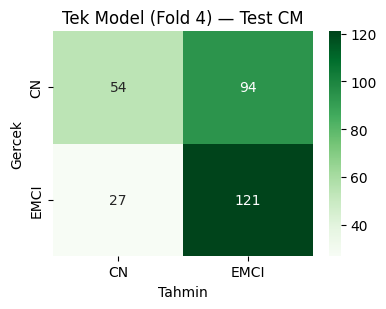

In [ ]:
# ===== EK HUCRE A: VALIDATION'da en iyi TEK fold'u sec, test et =====
import numpy as np

# Modellerin durdugu klasor (CONFIG zaman damgasi degisebildigi icin sabitliyoruz)
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23'

# 1) En iyi fold'u VALIDATION'a gore sec (TEST'e gore DEGIL!)
df_val = pd.read_csv(os.path.join(ANA_KLASOR, "deney_sonuclari.csv"))
en_iyi = df_val.loc[df_val['val_acc'].idxmax()]
en_iyi_fold = int(en_iyi['fold'])
print(f"VALIDATION'da en iyi fold: {en_iyi_fold}  (val_acc={en_iyi['val_acc']:.4f})\n")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}
test_loader = DataLoader(
    MRIMultiViewDataset(test_veriler, img_size=CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

# 3) Sadece o fold'un modelini yukle ve test et (fusion ciktisi)
model = multiview_olustur(CONFIG, dropout_rate=CONFIG["dropout"], fusion_dim=CONFIG["fusion_dim"])
model.load_state_dict(torch.load(
    os.path.join(ANA_KLASOR, f"multiview_fold_{en_iyi_fold}.pth"), weights_only=True))
y_true, y_pred, _ = multiview_degerlendir(model, test_loader)

# 4) Metrikler
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"{'='*60}\nTEK MODEL (Fold {en_iyi_fold}) — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title(f"Tek Model (Fold {en_iyi_fold}) — Test CM"); plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout(); plt.show()

Fold agirliklari (validation'dan):
   Fold 1: 0.154
   Fold 2: 0.169
   Fold 3: 0.224
   Fold 4: 0.236
   Fold 5: 0.218
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)
Toplam param   : 60,684,299
Egitilen param : 46,303,115 (76.30%)
Dropout        : 0.6
FFN ratio      : 1 (azaltildi)

VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.5946
   Precision    : 0.6029 | Recall: 0.5946 | F1: 0.5863
   Per-Class F1 : CN=0.5276 | EMCI=0.6450

              precision    recall  f1-score   support

          CN       0.63      0.45      0.53       148
        EMCI       0.57   

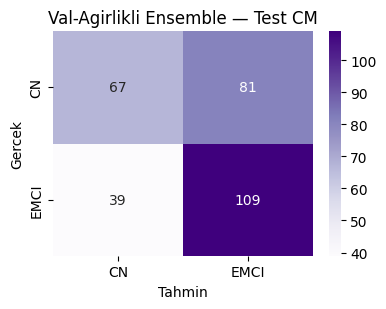

In [ ]:
# ===== EK HUCRE B: VALIDATION accuracy ile AGIRLIKLI ensemble =====
import numpy as np

ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23'

# 1) Fold agirliklari VALIDATION accuracy'den turetilir (test'ten DEGIL)
df_val = pd.read_csv(os.path.join(ANA_KLASOR, "deney_sonuclari.csv"))
# Daha belirgin fark icin (val_acc - 0.5) kullaniyoruz; iyi foldlar daha baskin
agirliklar = {int(row['fold']): max(row['val_acc'] - 0.5, 0.0) for _, row in df_val.iterrows()}
toplam = sum(agirliklar.values())
agirliklar = {k: v/toplam for k, v in agirliklar.items()}
print("Fold agirliklari (validation'dan):")
for k, v in agirliklar.items():
    print(f"   Fold {k}: {v:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}
test_loader = DataLoader(
    MRIMultiViewDataset(test_veriler, img_size=CONFIG["img_size"]),
    batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=CONFIG["num_workers"], pin_memory=True
)

# 3) Fusion olasiligi donduren yardimci
def fusion_olasilik(model, loader):
    model.eval(); sids=[]; probs=[]
    with torch.no_grad():
        for s, sag, ax, kor, lbl in loader:
            out = model(sag.to(DEVICE), ax.to(DEVICE), kor.to(DEVICE))
            probs.extend(torch.softmax(out, dim=1).cpu().numpy().tolist())
            sids.extend(list(s))
    return sids, probs

# 4) Her fold'u agirlikli topla
toplam_olasilik = {}
for fold in range(1, CONFIG["k_fold"] + 1):
    m_path = os.path.join(ANA_KLASOR, f"multiview_fold_{fold}.pth")
    if not os.path.exists(m_path): continue
    model = multiview_olustur(CONFIG, dropout_rate=CONFIG["dropout"], fusion_dim=CONFIG["fusion_dim"])
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, probs = fusion_olasilik(model, test_loader)
    w = agirliklar[fold]
    for sid, pr in zip(sids, probs):
        toplam_olasilik.setdefault(sid, np.zeros(2))
        toplam_olasilik[sid] += w * np.array(pr)
    del model; torch.cuda.empty_cache()

# 5) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\nVAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Purples',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("Val-Agirlikli Ensemble — Test CM"); plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout(); plt.show()

In [ ]:
import os, glob
kok = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models'
for d in sorted(glob.glob(kok + '/DenseNet_Self_Cross_Slice_FIXED_*')):
    pth = glob.glob(d + '/multiview_fold_*.pth')
    print(f"{os.path.basename(d)}  ->  {len(pth)} model")

DenseNet_Self_Cross_Slice_FIXED_2026_06_04_19_23  ->  5 model
DenseNet_Self_Cross_Slice_FIXED_2026_06_04_20_37  ->  0 model
